<h2>Contexte :</h2>
Ce projet s’appuie sur le problème 12 du livre *Python & Pandas* de Frédéric Bro et Chantal Remy, consacré à l’impact d’Airbnb sur l’hôtellerie parisienne.

À partir des données fournies (Airbnb, hôtels et géographie de Paris), l’objectif est d’analyser la concurrence entre ces deux formes d’hébergement.

Nous proposons ici une exploration et une analyse approfondie de ces données, en allant au-delà des traitements initiaux proposés dans l’ouvrage.

<h2>Données</h2>

Le projet repose sur trois jeux de données :

<ul>
<li><b>airbnb_paris.csv</b> : informations sur les logements Airbnb (localisation, type, prix, disponibilité, activité)</li>
<li><b>paris.geojson</b> : données géographiques des quartiers de Paris</li>
<li><b>hotels_paris.csv</b> : informations sur les hôtels (localisation, nombre d’étoiles, capacité)</li>
</ul>

<h2>Objectifs</h2>
<ul>
<li>Estimer le revenu minimal d’un logement Airbnb</li>
<li>Représenter une <b>carte choroplèthe</b> du revenu minimal moyen par quartier</li>
<li>Analyser la répartition des hôtels par quartier</li>
<li>Visualiser la densité des logements Airbnb (heatmap)</li>
<li>Comparer le nombre de logements Airbnb à la capacité hôtelière par quartier</li>
<li>Croiser ces informations dans une visualisation synthétique</li>
</ul>

<h3>Etape 1 : Que rapporte un logement ?</h3>

Import des données

In [1]:
import pandas as pd

airbnb = pd.read_csv('airbnb_paris.csv')
airbnb.head(10)

,Id,Id_Hote,Nom_Hote,Quartier,Latitude,Longitude,Type,Prix,Min_nuits,Dernier_avis,Avis_par_mois,Disponibilite
0,2788664,9024891,Jules,Ménilmontant,48.847907,2.401483,Entire_home/apt,55,3,2015-02-11,0.29,332
1,2912397,7734570,Olivier,Ménilmontant,48.861348,2.401395,Entire_home/apt,49,4,2015-08-22,3.36,171
2,830606,4350788,Catherine,Ménilmontant,48.862760,2.406240,Entire_home/apt,50,2,2015-08-23,1.41,101
3,4434726,9846692,Julie,Ménilmontant,48.855482,2.403873,Entire_home/apt,57,2,2015-07-07,1.88,349
4,6981068,12417393,Philippe,Ménilmontant,48.864844,2.401419,Entire_home/apt,45,14,NaN,NaN,365
5,5843730,27421781,Nastassja,Ménilmontant,48.852750,2.408663,Entire_home/apt,35,4,NaN,NaN,100
6,701878,3239549,Frederic,Ménilmontant,48.862274,2.402995,Private_room,60,1,2015-06-30,0.22,269
7,758510,3996403,Julien,Ménilmontant,48.857208,2.396639,Entire_home/apt,50,2,2014-09-19,0.17,214
8,1199956,4229832,Mile,Ménilmontant,48.858479,2.403650,Entire_home/apt,117,7,NaN,NaN,361
9,3317989,16750576,Renaud,Ménilmontant,48.867474,2.396858,Entire_home/apt,180,2,2015-08-20,2.88,329


In [2]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35428 entries, 0 to 35427
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             35428 non-null  int64  
 1   Id_Hote        35428 non-null  int64  
 2   Nom_Hote       30573 non-null  object 
 3   Quartier       35428 non-null  object 
 4   Latitude       35428 non-null  float64
 5   Longitude      35428 non-null  float64
 6   Type           35428 non-null  object 
 7   Prix           35428 non-null  int64  
 8   Min_nuits      35428 non-null  int64  
 9   Dernier_avis   25213 non-null  object 
 10  Avis_par_mois  25213 non-null  float64
 11  Disponibilite  35428 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


Création d’une variable représentant la durée minimale de séjour.

In [3]:
airbnb['Duree_min_an'] = 12 * airbnb['Min_nuits'] * airbnb['Avis_par_mois']
airbnb.tail()

,Id,Id_Hote,Nom_Hote,Quartier,Latitude,Longitude,Type,Prix,Min_nuits,Dernier_avis,Avis_par_mois,Disponibilite,Duree_min_an
35423,6907666,23025598,Bogena,Luxembourg,48.852038,2.336728,Entire_home/apt,111,5,NaN,NaN,0,NaN
35424,150937,726874,Jonathan,Luxembourg,48.845581,2.331691,Entire_home/apt,350,3,2015-08-12,0.83,323,29.88
35425,4990889,9134315,Jean-Edouard,Luxembourg,48.844086,2.331177,Private_room,75,2,2015-08-14,2.35,305,56.40
35426,601053,2157959,Olivia,Luxembourg,48.856740,2.339274,Entire_home/apt,119,2,2015-08-11,0.94,312,22.56
35427,7170955,37560127,Laure,Luxembourg,48.849519,2.338540,Entire_home/apt,80,1,2015-08-20,4.57,34,54.84


<b>Commentaires :</b> Ce calcul repose sur la variable <i>Avis_par_mois</i>, qui contient de nombreuses valeurs manquantes. De plus, la méthode de calcul de ces moyennes n’est pas précisée, ce qui peut introduire des biais. Ce point sera approfondi par la suite.

On vérifie la cohérence entre la durée minimale estimée et la disponibilité du logement.

In [4]:
# logements pour lesquels la durée estimée dépasse la disponibilité
airbnb[airbnb['Duree_min_an'] > airbnb['Disponibilite']]

,Id,Id_Hote,Nom_Hote,Quartier,Latitude,Longitude,Type,Prix,Min_nuits,Dernier_avis,Avis_par_mois,Disponibilite,Duree_min_an
20,6961917,36426574,Stephen,Ménilmontant,48.860306,2.388817,Entire_home/apt,55,3,2015-08-26,2.73,0,98.28
22,4605116,19905908,Orianne & Aurelien,Panthéon,48.847567,2.352989,Entire_home/apt,90,4,2015-08-23,1.15,0,55.20
29,62266,302914,Catherine,Panthéon,48.852504,2.346214,Entire_home/apt,100,4,2015-08-27,1.67,33,80.16
32,2767214,12724287,Véronique,Panthéon,48.843586,2.352268,Entire_home/apt,270,4,2014-07-28,0.07,0,3.36
34,5047810,25587141,Anna,Panthéon,48.851909,2.344494,Entire_home/apt,39,5,2015-08-28,5.37,89,322.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35401,4534804,5577796,Liliana,Louvre,48.861732,2.344066,Entire_home/apt,185,3,2015-08-24,3.99,82,143.64
35411,637754,3181891,NaN,Louvre,48.863640,2.349041,Entire_home/apt,95,3,2015-08-30,2.41,42,86.76
35417,237949,1247676,Anne Lise,Louvre,48.863477,2.349439,Entire_home/apt,69,4,2015-08-30,1.42,50,68.16
35422,5255062,23025598,Bogena,Luxembourg,48.853132,2.330625,Entire_home/apt,347,4,2015-08-11,0.62,25,29.76


In [5]:
airbnb['Duree_min_an'].describe()

count    25213.000000
mean        43.123887
std        132.325564
min          0.240000
25%         12.000000
50%         27.360000
75%         55.200000
max      16545.600000
Name: Duree_min_an, dtype: float64

<b>Commentaires :</b> Certaines durées minimales estimées dépassent le nombre de jours de disponibilité, ce qui révèle des incohérences dans les données. De plus, la valeur maximale de <i>Duree_min_an</i> (16545.6) est manifestement aberrante, probablement due à une erreur de saisie.

Par ailleurs, ce calcul repose sur l’hypothèse que <i>Avis_par_mois</i> est représentatif du nombre de locations, ce qui est discutable : tous les locataires ne laissent pas d’avis, et plusieurs avis peuvent être associés à un même séjour.

<b>Bénéfice minimum estimé</b>

In [6]:
airbnb['Revenu_moyen'] = airbnb['Prix'] * airbnb['Duree_min_an']
airbnb.tail()

,Id,Id_Hote,Nom_Hote,Quartier,Latitude,Longitude,Type,Prix,Min_nuits,Dernier_avis,Avis_par_mois,Disponibilite,Duree_min_an,Revenu_moyen
35423,6907666,23025598,Bogena,Luxembourg,48.852038,2.336728,Entire_home/apt,111,5,NaN,NaN,0,NaN,NaN
35424,150937,726874,Jonathan,Luxembourg,48.845581,2.331691,Entire_home/apt,350,3,2015-08-12,0.83,323,29.88,10458.00
35425,4990889,9134315,Jean-Edouard,Luxembourg,48.844086,2.331177,Private_room,75,2,2015-08-14,2.35,305,56.40,4230.00
35426,601053,2157959,Olivia,Luxembourg,48.856740,2.339274,Entire_home/apt,119,2,2015-08-11,0.94,312,22.56,2684.64
35427,7170955,37560127,Laure,Luxembourg,48.849519,2.338540,Entire_home/apt,80,1,2015-08-20,4.57,34,54.84,4387.20


In [7]:
# On fait un petit nettoyage afin de garder les valeurs exploitables
R = airbnb.query('Duree_min_an > 0 & Duree_min_an <= Disponibilite')
R.head()

,Id,Id_Hote,Nom_Hote,Quartier,Latitude,Longitude,Type,Prix,Min_nuits,Dernier_avis,Avis_par_mois,Disponibilite,Duree_min_an,Revenu_moyen
0,2788664,9024891,Jules,Ménilmontant,48.847907,2.401483,Entire_home/apt,55,3,2015-02-11,0.29,332,10.44,574.20
1,2912397,7734570,Olivier,Ménilmontant,48.861348,2.401395,Entire_home/apt,49,4,2015-08-22,3.36,171,161.28,7902.72
2,830606,4350788,Catherine,Ménilmontant,48.862760,2.406240,Entire_home/apt,50,2,2015-08-23,1.41,101,33.84,1692.00
3,4434726,9846692,Julie,Ménilmontant,48.855482,2.403873,Entire_home/apt,57,2,2015-07-07,1.88,349,45.12,2571.84
6,701878,3239549,Frederic,Ménilmontant,48.862274,2.402995,Private_room,60,1,2015-06-30,0.22,269,2.64,158.40


In [8]:
R['Revenu_moyen'].describe()

count     21839.000000
mean       3740.167154
std        5104.631389
min          10.800000
25%         842.400000
50%        2065.800000
75%        4621.320000
max      184017.600000
Name: Revenu_moyen, dtype: float64

<b>Commentaires :</b> Avant toute interprétation, il faut noter que ces valeurs peuvent être éloignées de la réalité. Le prix par nuit (<i>Prix</i>) ne correspond pas nécessairement au revenu net du propriétaire (charges, frais, etc. non pris en compte). Il s’agit donc d’une estimation de revenu brut.

<h3>Revenu moyen minimal par quartier</h3>

In [9]:
df = R.groupby('Quartier')['Revenu_moyen'].mean().reset_index()
df

,Quartier,Revenu_moyen
0,Batignolles-Monceau,3035.002885
1,Bourse,5172.277187
2,Buttes-Chaumont,1845.423135
3,Buttes-Montmartre,2741.074808
4,Entrepôt,3406.593408
5,Gobelins,2485.679467
6,Hôtel-de-Ville,6757.360049
7,Louvre,6506.480787
8,Luxembourg,6390.998735
9,Ménilmontant,1729.580000


Dans le quartier Batignolles-Monceau, le revenu annuel minimal moyen estimé pour un logement est d’environ 3035 €.

<b>Première visualisation</b>

In [10]:
import geopandas as gpd
geojson = gpd.read_file('paris.geojson')
geojson.head()

,perimetre,surf_km2,quartier,ar,geometry
0,8282.011886,3.665442,Popincourt,11,"POLYGON ((2.39624 48.85415, 2.39708 48.85308, ..."
1,13678.798315,8.494994,Vaugirard,15,"POLYGON ((2.29932 48.85217, 2.30088 48.85118, ..."
2,11546.546526,7.149311,Gobelins,13,"POLYGON ((2.37491 48.83801, 2.37698 48.8361, 2..."
3,4519.263648,1.170883,Temple,3,"POLYGON ((2.36383 48.8675, 2.36389 48.86747, 2..."
4,8099.424883,4.090057,Palais-Bourbon,7,"POLYGON ((2.3209 48.86306, 2.32094 48.86305, 2..."


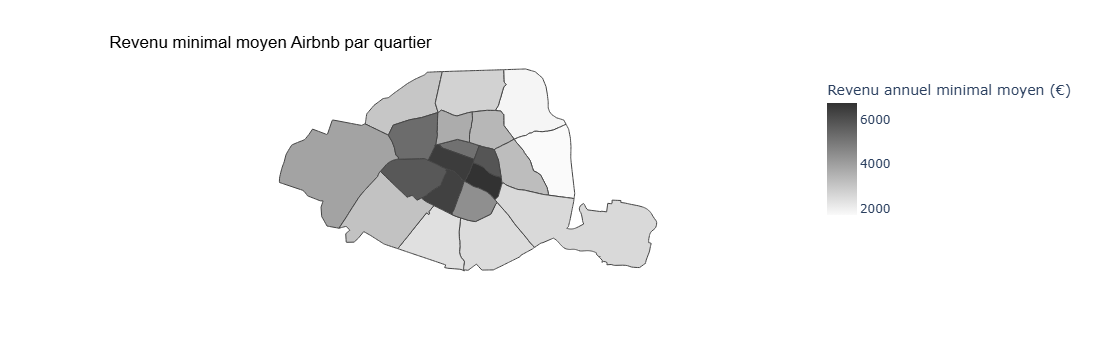

In [11]:
import plotly.express as px

fig1 = px.choropleth(
    data_frame = df,
    locations = 'Quartier',
    geojson = geojson,
    featureidkey = 'properties.quartier',
    color = 'Revenu_moyen',
    color_continuous_scale = [(0, 'rgb(250, 250, 250)'),
                             (0.25, 'rgb(200, 200, 200)'),
                             (0.5, 'rgb(150, 150, 150)'),
                             (0.75, 'rgb(100, 100, 100)'),
                             (1, 'rgb(50, 50, 50)')]
)
fig1.update_layout(
    coloraxis = {'colorbar' : {'len' : 0.7,
                              'x' : 0.95,
                              'y' : 0.6,
                              'title' : 'Revenu annuel minimal moyen (€)'
                              }
                },
    title = {'text' : "Revenu minimal moyen Airbnb par quartier",
             'font' : {'family' : 'Arial',
                       'color' : 'black'},
             'y' : 0.9,
             'x' : 0.1},
    showlegend = True,
)
fig1.update_geos(
    fitbounds = 'locations', visible = False,
    projection = {'type' : 'transverse mercator'})
fig1.write_image('carte1_airbnb.png', scale=2)
fig1.show()

<b>Interprétation</b>
<ul>
    <li>Les revenus annuels minimaux estimés sont plus élevés dans le centre de Paris, notamment dans les arrondissements 1 à 8.</li>
</ul>

<h3>Etape 2 : Occupation par quartier</h3>

<b>Densité des logements Airbnb</b>

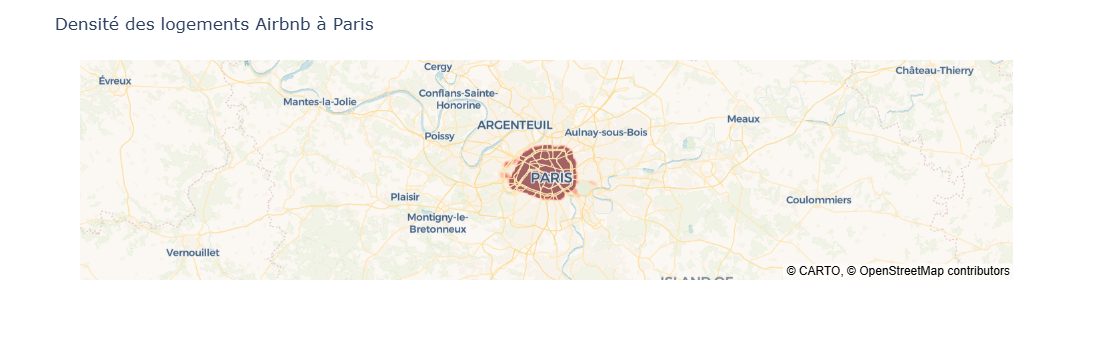

In [12]:
fig2 = px.density_map(
    data_frame = airbnb,
    lat = 'Latitude', lon = 'Longitude',
    radius = 5,
    color_continuous_scale='Reds',
    opacity = 0.6
)

fig2.update_layout(
    mapbox = {'style' : 'open-street-map',
             'center' : {'lat' : airbnb['Latitude'].mean(),
                        'lon' : airbnb['Longitude'].mean()},
             'zoom' : 11.4
             },
    title = "Densité des logements Airbnb à Paris",
    coloraxis_showscale = False
)
fig2.show()

<b>Observations :</b>
<ul>
<li>Une forte concentration de logements apparaît sur la rive droite, notamment autour de l’Hôtel de Ville et jusqu’à Montmartre.</li>
<li>Sur la rive gauche, la densité est également élevée autour des quartiers du Palais Bourbon, du Luxembourg et du Panthéon.</li>
</ul>

<b>Nombre de logements Airbnb par quartier</b>

In [13]:
N = R['Quartier'].value_counts().reset_index().rename(columns={'count':'nb_airbnb'})
N

,Quartier,nb_airbnb
0,Buttes-Montmartre,2396
1,Popincourt,1696
2,Vaugirard,1565
3,Batignolles-Monceau,1442
4,Entrepôt,1426
5,Passy,1191
6,Buttes-Chaumont,1091
7,Panthéon,1067
8,Ménilmontant,1038
9,Opéra,991


<h3>Étape 3 : Nombre d’hôtels par quartier</h3>

In [14]:
# chargement des données des hôtels
hotels = pd.read_csv('hotels_paris.csv')

# aperçu
hotels.head()

,nom_commercial,ar,quartier,etoiles,nb_chambres,lat,long
0,HÔTEL LOUVRE MONTANA,1,Louvre,4,25,48.864480,2.331768
1,HÔTEL LOUVRE RICHELIEU,1,Louvre,3,13,48.866477,2.337195
2,RELAIS DES HALLES,1,Louvre,3,19,48.863213,2.348910
3,HÔTEL OPÉRA MAINTENON,1,Louvre,2,19,48.866795,2.335859
4,HÔTEL SNOB,1,Louvre,4,24,48.862409,2.349543


In [15]:
etoiles = pd.crosstab(hotels['quartier'], hotels['etoiles'])
etoiles

etoiles,1,2,3,4,5
quartier,,,,,
Batignolles-Monceau,4,13,57,29,1
Bourse,1,3,17,16,1
Buttes-Chaumont,0,10,10,2,0
Buttes-Montmartre,2,13,20,12,0
Entrepôt,5,28,49,15,1
Gobelins,0,10,22,7,0
Hôtel-de-Ville,1,4,18,6,1
Louvre,0,6,21,25,14
Luxembourg,1,9,37,38,6


In [16]:
# export de la table des étoiles par quartier
etoiles.to_csv('etoiles.csv')

<b>Répartition des hôtels par nombre d’étoiles</b>

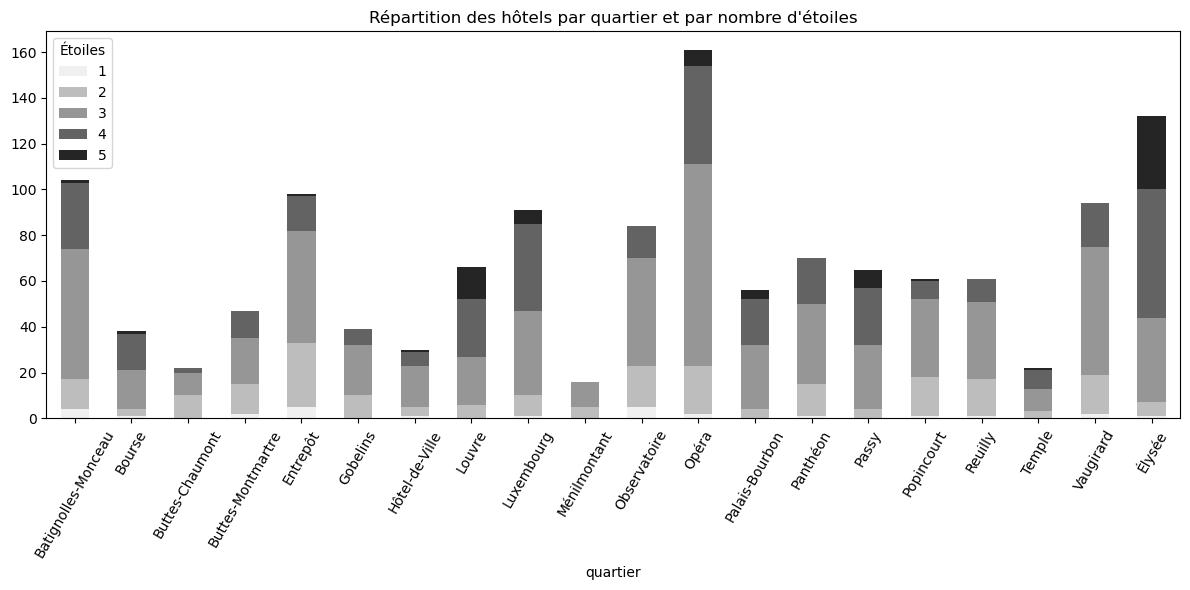

In [17]:
import matplotlib.pyplot as plt

etoiles.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=['#f0f0f0','#bdbdbd','#969696','#636363','#252525']
)

plt.legend(title="Étoiles")
plt.title("Répartition des hôtels par quartier et par nombre d'étoiles")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

<ul>
<li>Les hôtels 3 et 4 étoiles sont majoritaires à Paris.</li>
<li>Les hôtels 5 étoiles sont principalement concentrés dans les quartiers du Louvre, de l’Élysée et de Passy.</li>
</ul>

<h3>Étape 4 : Comparaison entre logements Airbnb et capacité hôtelière</h3>

<b>Nombre de chambres d'hôtel par quartier</b>

In [18]:
chambres = hotels.groupby('quartier')['nb_chambres'].sum().reset_index()
chambres = chambres.rename(columns={'quartier':'Quartier'})
chambres

,Quartier,nb_chambres
0,Batignolles-Monceau,7035
1,Bourse,1703
2,Buttes-Chaumont,2279
3,Buttes-Montmartre,2839
4,Entrepôt,4851
5,Gobelins,2020
6,Hôtel-de-Ville,817
7,Louvre,3841
8,Luxembourg,3362
9,Ménilmontant,758


<b>Ratio logements Airbnb / chambres d’hôtel par quartier</b>

In [19]:
Ratio = pd.merge(N, chambres, on='Quartier')
Ratio

,Quartier,nb_airbnb,nb_chambres
0,Buttes-Montmartre,2396,2839
1,Popincourt,1696,2901
2,Vaugirard,1565,6218
3,Batignolles-Monceau,1442,7035
4,Entrepôt,1426,4851
5,Passy,1191,2816
6,Buttes-Chaumont,1091,2279
7,Panthéon,1067,2637
8,Ménilmontant,1038,758
9,Opéra,991,7751


In [ ]:
Ratio['ratio_airbnb_chambres'] = (Ratio['nb_airbnb'] / Ratio['nb_chambres']).round(1)
Ratio

Dans le quartier Batignolles-Monceau, l’offre Airbnb est relativement faible, avec environ 2 logements pour 10 chambres d’hôtel.

<b>Ratio logements Airbnb / chambres d’hôtel</b>

In [ ]:
geojson['quartier'] = geojson['quartier'].str.strip().str.lower()
Ratio['Quartier'] = Ratio['Quartier'].str.strip().str.lower()

geojson = geojson.merge(
    Ratio[['Quartier', 'ratio_airbnb_chambres']],
    left_on='quartier',
    right_on='Quartier',
    how='left'
)

In [ ]:
geojson.head()

In [ ]:
# on vérifie que tout à bien matché
set(geojson['quartier']) - set(Ratio['Quartier'])

### Visualisation du ratio Airbnb / capacité hôtelière

Afin de comparer l’offre Airbnb à la capacité hôtelière, on calcule pour chaque quartier le ratio entre le nombre de logements Airbnb et le nombre de chambres d’hôtel.

Ce ratio permet d’identifier les zones où Airbnb est dominant par rapport aux hôtels, et inversement.

La carte suivante représente cette répartition à l’échelle des quartiers parisiens.


In [ ]:
fig = px.choropleth(
    data_frame=geojson,
    geojson=geojson.geometry,
    locations=geojson.index,
    color="ratio_airbnb_chambres",
    color_continuous_scale="Reds",
    hover_data={
        "quartier": True,
        "ratio_airbnb_chambres": True
    }
)

fig.update_layout(
    title="Ratio logements Airbnb / chambres d’hôtel par quartier",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.show()

<h3>Interprétation</h3>

Les quartiers présentant la plus forte concurrence d’Airbnb sont :
<ul>
<li>Ménilmontant (20e arrondissement), avec environ 1,4 logement Airbnb par chambre d’hôtel.</li>
<li>Temple (3e arrondissement), avec environ 1,1 logement Airbnb par chambre d’hôtel.</li>
<li>Hôtel de Ville (4e arrondissement), avec un ratio proche de 1.</li>
</ul>

À l’inverse, certains quartiers présentent une concurrence plus modérée mais des revenus élevés pour les logements Airbnb :
<ul>
<li>Le Louvre (2e arrondissement) présente un ratio équilibré (environ 1 logement Airbnb pour 1 chambre d’hôtel), mais un revenu annuel moyen élevé (environ 6500 €).</li>
<li>Le Luxembourg (6e arrondissement) affiche un ratio plus faible (environ 3 logements pour 10 chambres d’hôtel), tout en conservant un revenu moyen élevé (environ 6400 €).</li>
</ul>

<h3>Étape 5 : Analyse croisée de la concurrence Airbnb et de la structure hôtelière</h3>

In [ ]:
import numpy as np


# --- copie ---
etoiles_df = etoiles.copy()
ratio_series = Ratio.set_index('Quartier')['ratio_airbnb_chambres']

# --- harmonisation des noms ---
etoiles_df.index = etoiles_df.index.str.strip().str.lower()
ratio_series.index = ratio_series.index.str.strip().str.lower()

# --- alignement sécurisé ---
etoiles_df = etoiles_df.reindex(ratio_series.index)

# --- positions ---
x = np.arange(len(etoiles_df.index))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12,6))

# --- barres empilées (hôtels) ---
bottom = np.zeros(len(etoiles_df))

for col in etoiles_df.columns:
    ax1.bar(x - width/2, etoiles_df[col], width,
            bottom=bottom, label=f"{col} étoiles")
    bottom += etoiles_df[col]

ax1.set_ylabel("Nombre d'hôtels")

# --- axe secondaire (ratio) ---
ax2 = ax1.twinx()

ax2.bar(x + width/2, ratio_series.values, width,
        color='black', alpha=0.6, label='Ratio Airbnb / chambres')

ax2.set_ylabel("Ratio Airbnb / chambres")

# --- axe x ---
ax1.set_xticks(x)
ax1.set_xticklabels(etoiles_df.index, rotation=45)

# --- titre ---
plt.title("Répartition des hôtels et concurrence Airbnb par quartier")

# --- légende combinée ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2)

plt.tight_layout()
plt.show()

<ul>
<li>Dans les 20e, 11e, 3e et 2e arrondissements, la concurrence d’Airbnb reste élevée malgré la présence d’hôtels, ce qui suggère une forte implantation de l’offre locative dans ces zones.</li>
<li>À l’inverse, dans des quartiers comme les 8e et 1er arrondissements, où les hôtels haut de gamme (4* et 5*) sont plus présents, le ratio est plus faible (environ 1 logement Airbnb pour 10 chambres d’hôtel).</li>
</ul>

<b>On observe ainsi que la concurrence d’Airbnb semble plus marquée dans les segments d’hôtellerie intermédiaire (2* et 3*), tandis que les hôtels haut de gamme apparaissent moins directement affectés.</b>